In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading dataset
df = pd.read_csv("/content/survey.csv")

df = df.drop_duplicates()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df = df.dropna(subset=["Age"])
df["Age"] = df["Age"].astype(int)

# BPM outlier removal (implausible values)
df.loc[(df["BPM"] < 30) | (df["BPM"] >= 240), "BPM"] = np.nan

print(f"Rows after cleaning: {len(df)}")
print(df[["Age", "Hours per day", "BPM", "Anxiety", "Depression", "Insomnia", "OCD"]].describe().round(2))

Rows after cleaning: 608
          Age  Hours per day     BPM  Anxiety  Depression  Insomnia     OCD
count  608.00         608.00  608.00   608.00      608.00    608.00  608.00
mean    24.65           3.71  123.92     5.86        4.87      3.79    2.65
std     11.41           3.08   32.17     2.76        2.99      3.10    2.85
min     10.00           0.00   40.00     0.00        0.00      0.00    0.00
25%     18.00           2.00  100.00     4.00        2.00      1.00    0.00
50%     21.00           3.00  120.00     6.00        5.00      3.00    2.00
75%     27.00           5.00  144.00     8.00        7.00      6.00    5.00
max     89.00          24.00  220.00    10.00       10.00     10.00   10.00


In [ ]:
def iqr_bounds(series):
    """Return (lower, upper) IQR fences for a numeric series."""
    q1  = series.quantile(0.25)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Columns to treat — only continuous variables used as clustering features
# Mental health outcomes are left untouched (bounded scale, no outliers)
OUTLIER_COLS = ["Hours per day", "BPM"]

print(f"Rows before outlier removal: {len(df)}")

for col in OUTLIER_COLS:
    lo, hi  = iqr_bounds(df[col].dropna())
    before  = len(df)
    df      = df[(df[col].isna()) | ((df[col] >= lo) & (df[col] <= hi))]
    removed = before - len(df)
    print(f"  {col}: bounds=[{lo:.1f}, {hi:.1f}]  → removed {removed} rows")

print(f"\nRows after outlier removal: {len(df)}")
print(df[OUTLIER_COLS].describe().round(2))

Rows before outlier removal: 608
  Hours per day: bounds=[-2.5, 9.5]  → removed 36 rows
  BPM: bounds=[35.1, 208.1]  → removed 5 rows

Rows after outlier removal: 567
       Hours per day     BPM
count         567.00  567.00
mean            3.17  122.49
std             2.01   30.93
min             0.00   40.00
25%             2.00  100.00
50%             3.00  120.00
75%             4.00  141.00
max             9.00  208.00


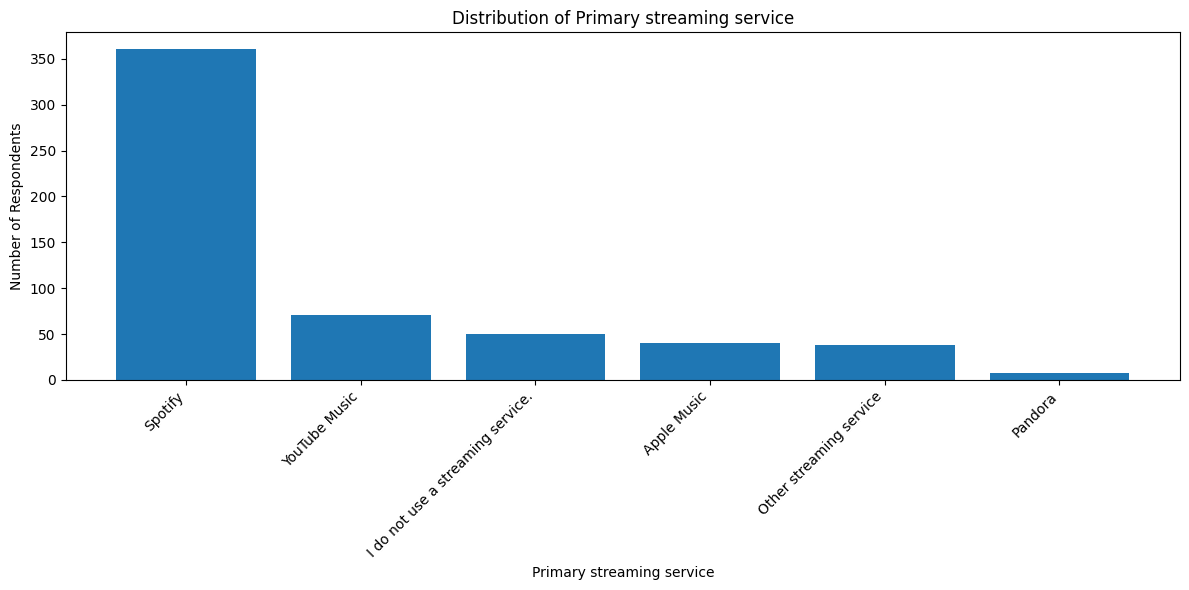

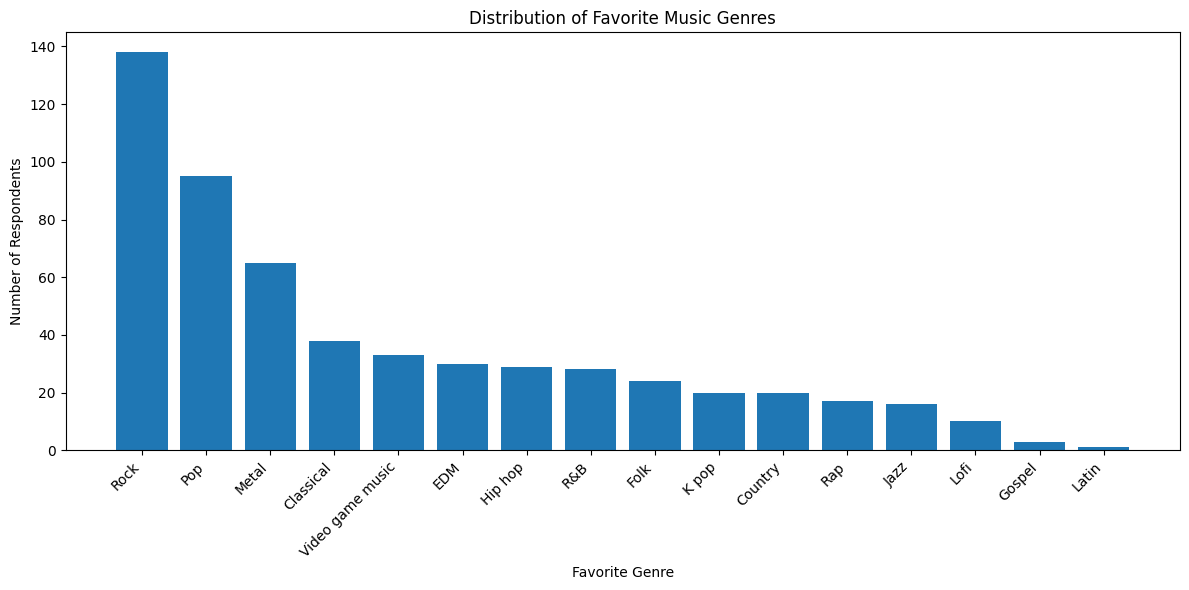

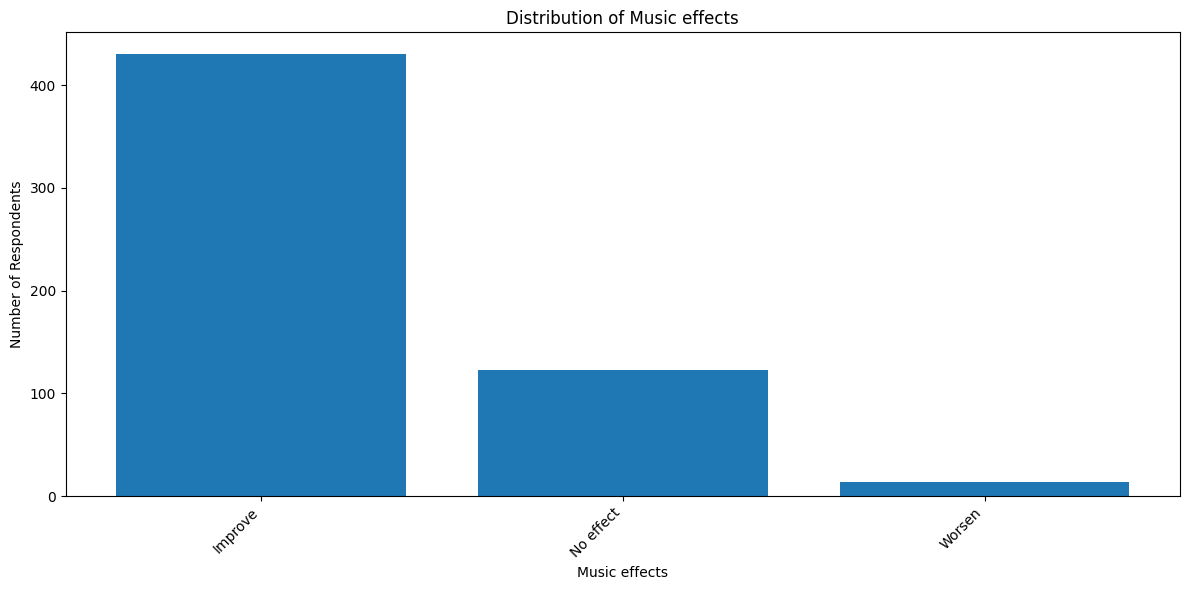

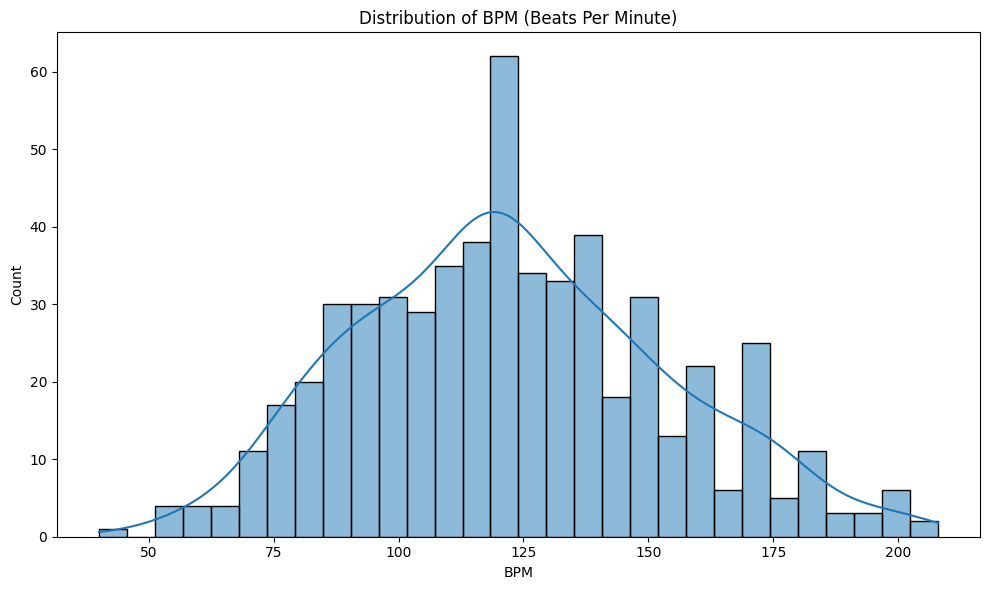

In [ ]:
#Primary streaming service
plt.figure(figsize=(12, 6))
genre_counts = df['Primary streaming service'].value_counts()
plt.bar(genre_counts.index, genre_counts.values)
plt.title('Distribution of Primary streaming service')
plt.xlabel('Primary streaming service')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#favourite genre
plt.figure(figsize=(12, 6))
genre_counts = df['Fav genre'].value_counts()
plt.bar(genre_counts.index, genre_counts.values)
plt.title('Distribution of Favorite Music Genres')
plt.xlabel('Favorite Genre')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Music effects
plt.figure(figsize=(12, 6))
genre_counts = df['Music effects'].value_counts()
plt.bar(genre_counts.index, genre_counts.values)
plt.title('Distribution of Music effects')
plt.xlabel('Music effects')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#bpm
plt.figure(figsize=(10, 6))
sns.histplot(df['BPM'].dropna(), kde=True, bins=30, palette='viridis')
plt.title('Distribution of BPM (Beats Per Minute)')
plt.xlabel('BPM')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
display(df["BPM"].describe())
df["BPM"].isna().sum()

,BPM
count,567.000000
mean,122.488536
std,30.933123
min,40.000000
25%,100.000000
50%,120.000000
75%,141.000000
max,208.000000


np.int64(0)

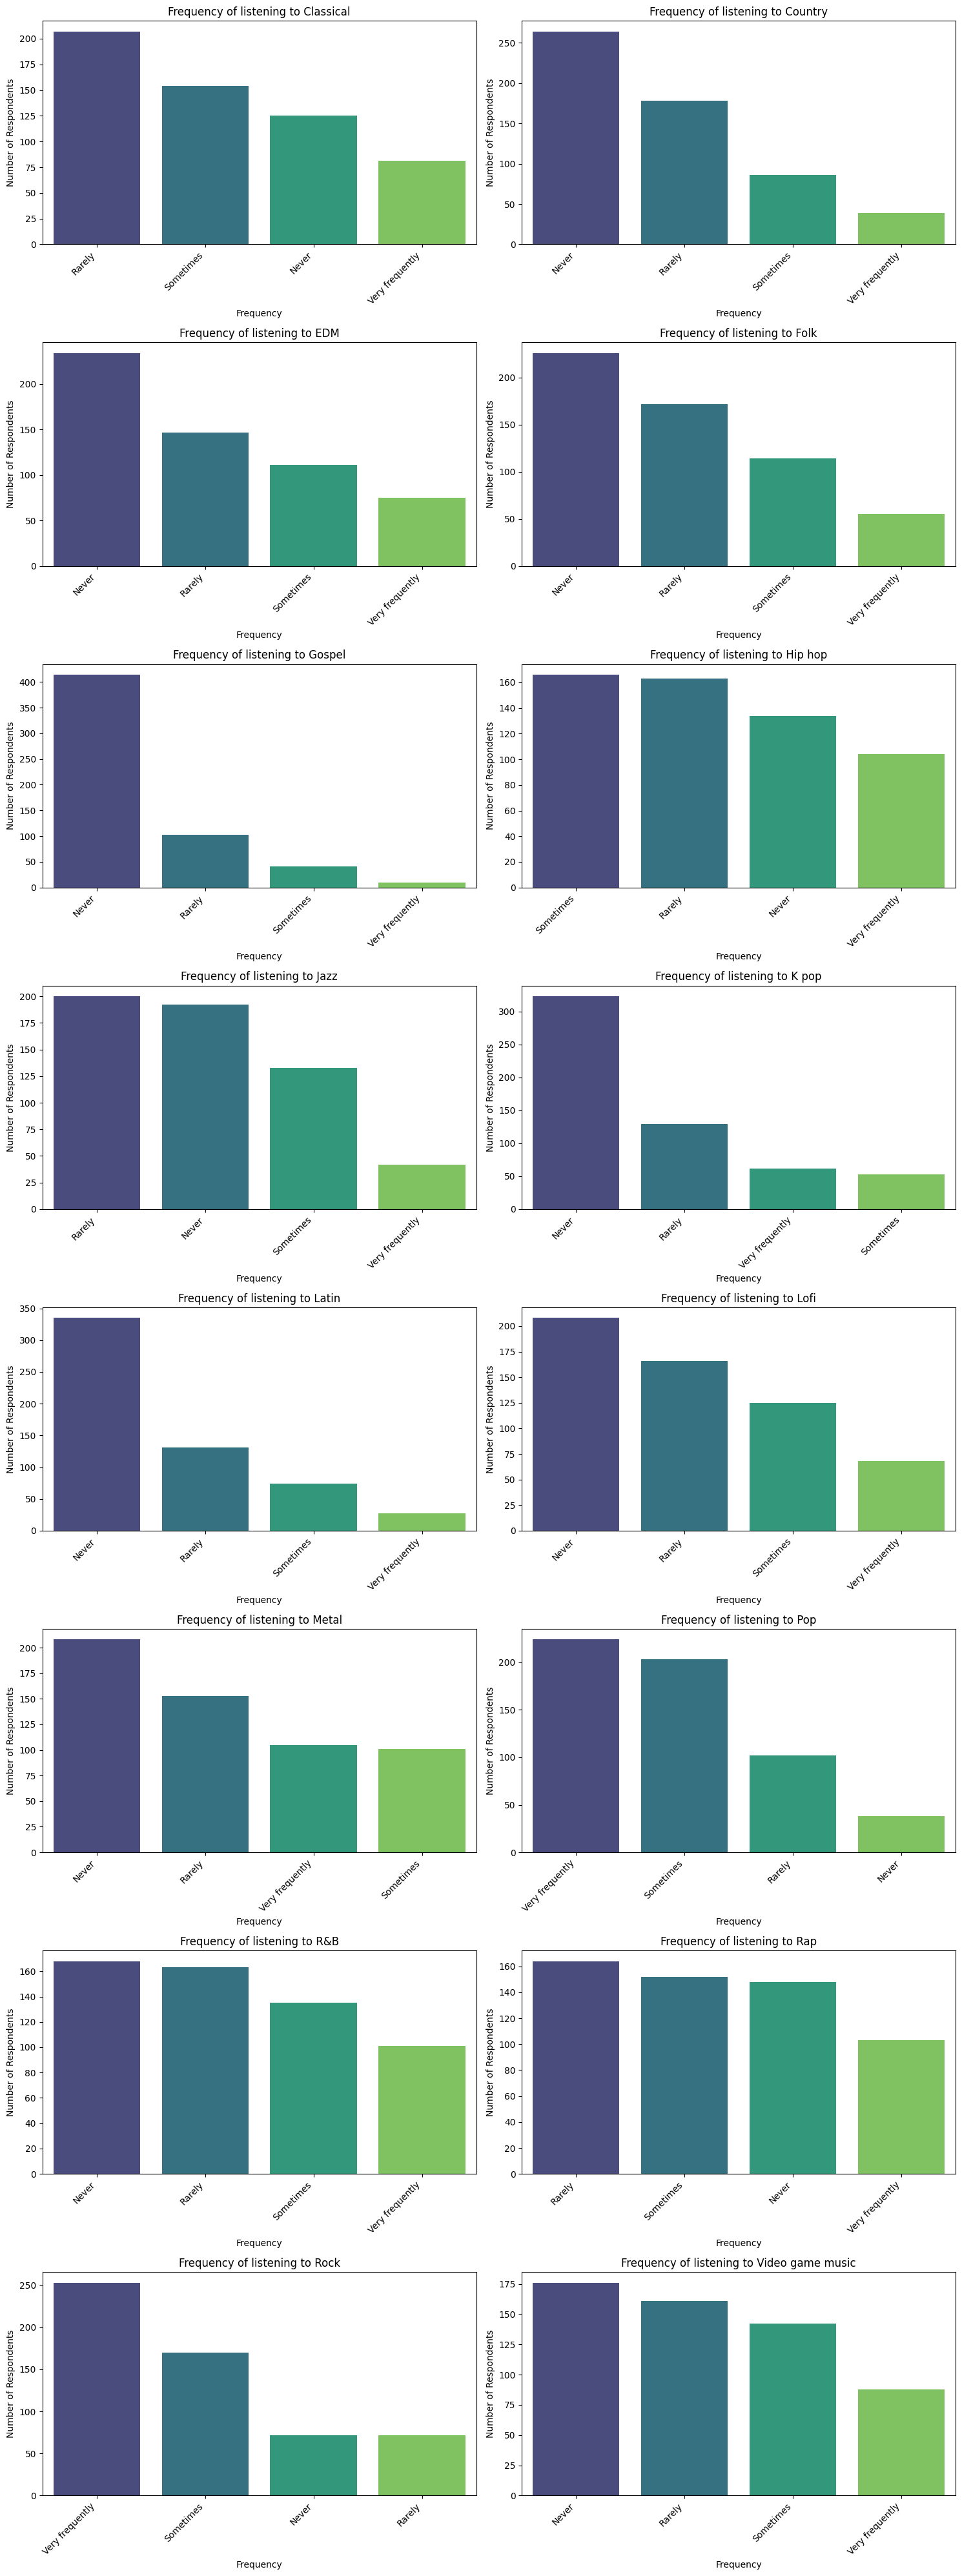

In [ ]:
frequency_columns = [col for col in df.columns if col.startswith('Frequency [')]

num_rows = (len(frequency_columns) + 1) // 2

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(frequency_columns):
    plt.subplot(num_rows, 2, i + 1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')

    genre_name = col.replace("Frequency [", "").replace("]", "")
    plt.title(f'Frequency of listening to {genre_name}')
    plt.xlabel('Frequency')
    plt.ylabel('Number of Respondents')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

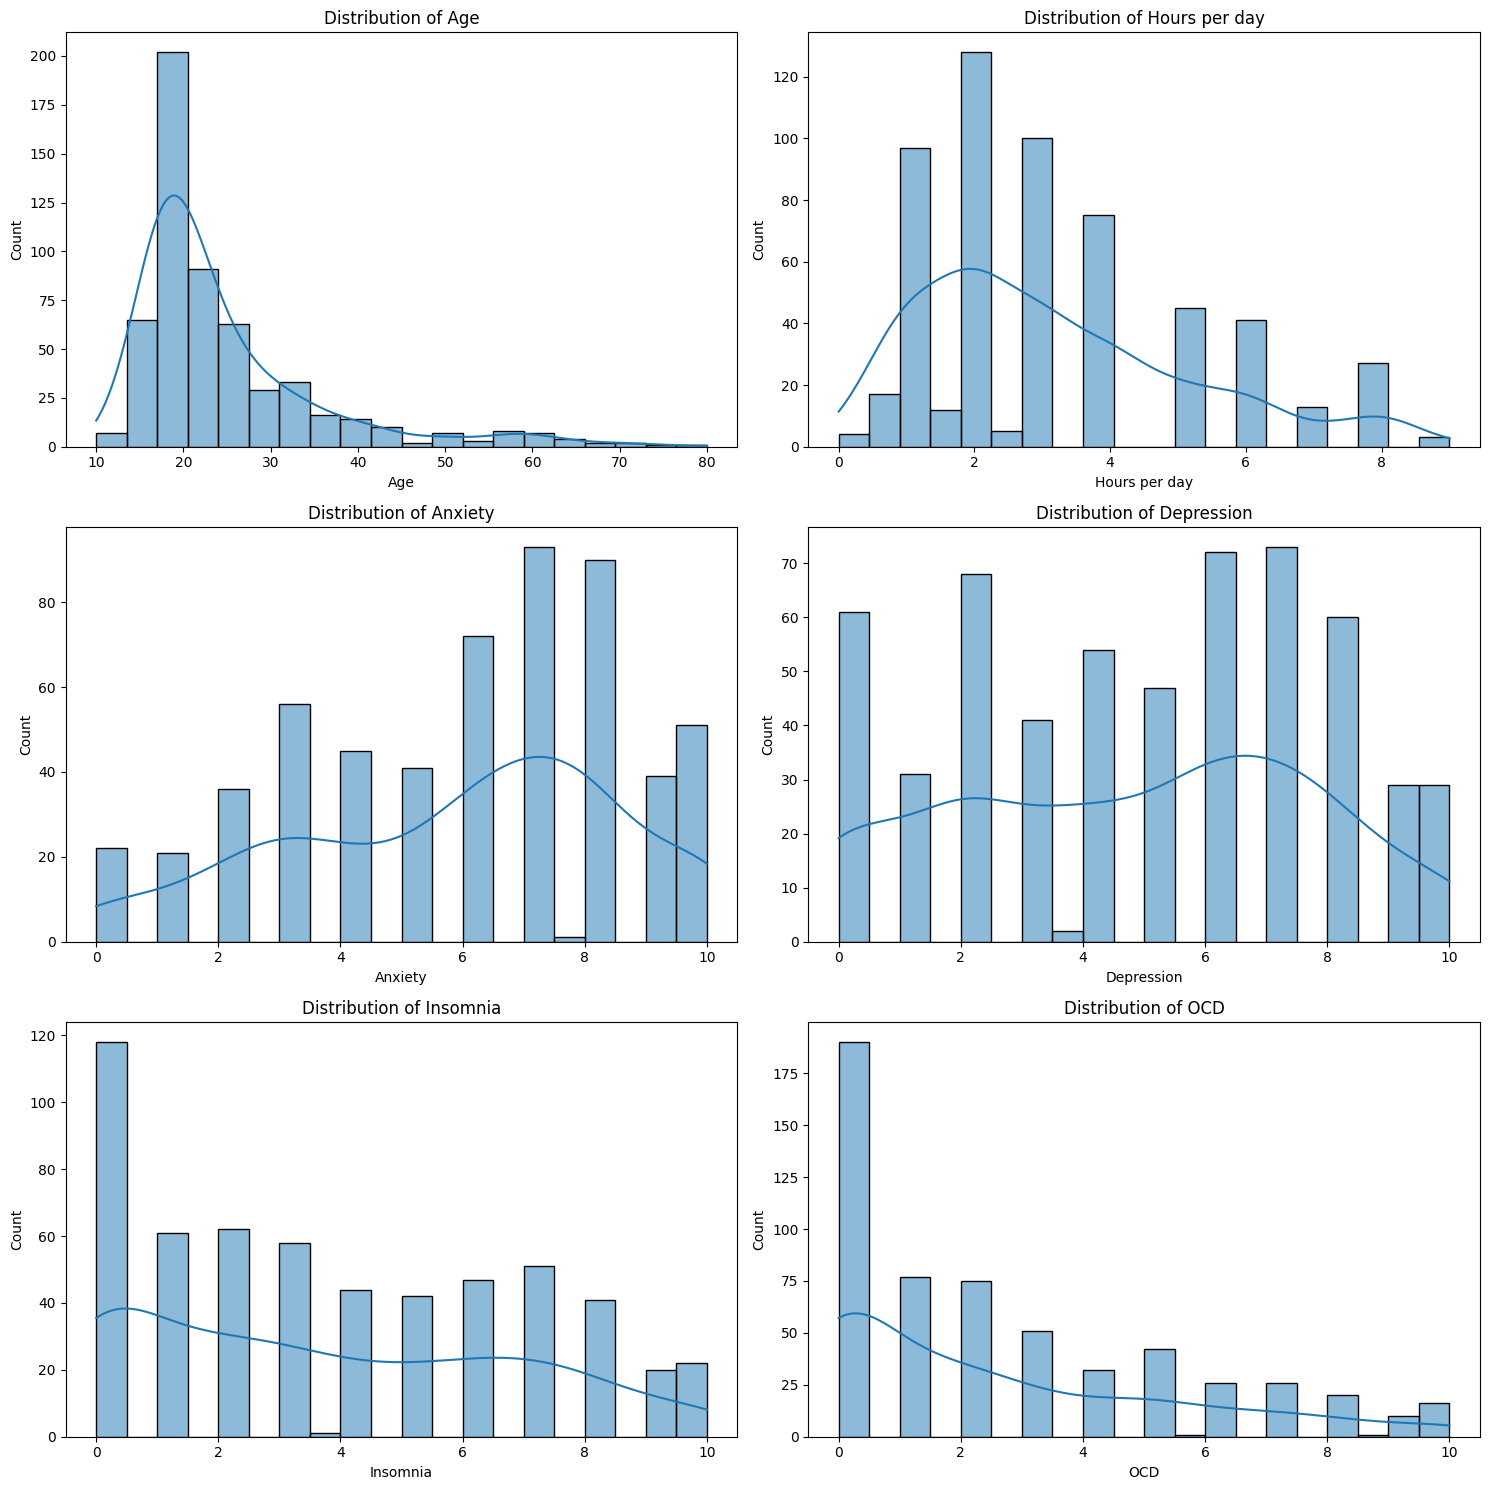

In [ ]:
numerical_cols = ['Age', 'Hours per day', 'Anxiety', 'Depression', 'Insomnia', 'OCD']

num_cols = 2
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=20, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

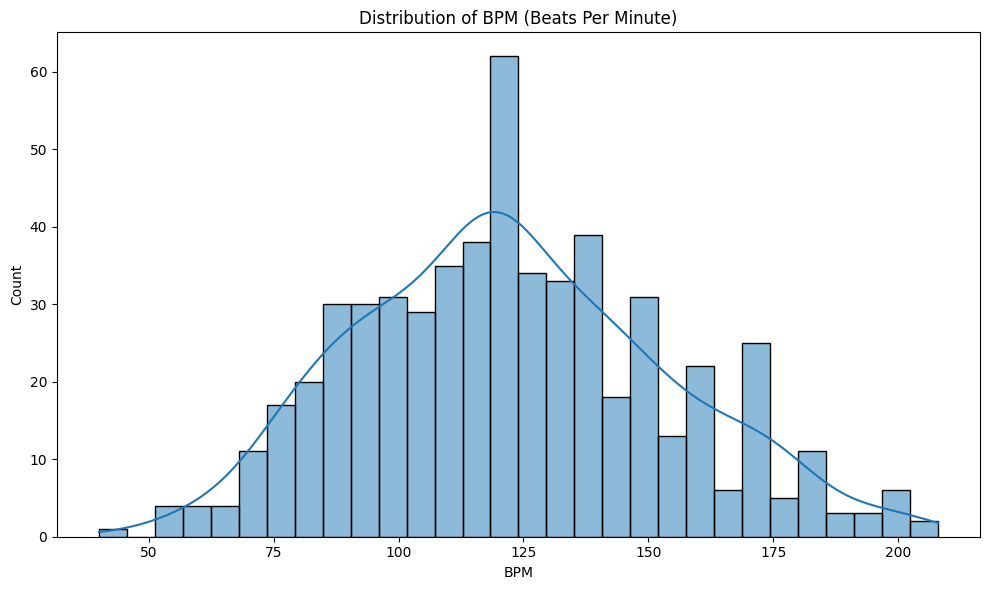

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['BPM'].dropna(), kde=True, bins=30, palette='viridis')
plt.title('Distribution of BPM (Beats Per Minute)')
plt.xlabel('BPM')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Splitting Variables
OUTCOMES  = ["Anxiety", "Depression", "Insomnia", "OCD", "Music effects"]
EXCLUDE   = ["Timestamp", "Permissions"] + OUTCOMES

frequency_vars = [c for c in df.columns if c.startswith("Frequency [") and not c.endswith("_enc")]
binary_vars    = ["While working", "Instrumentalist", "Composer", "Exploratory", "Foreign languages"]
numeric_vars   = ["Hours per day", "BPM"]
nominal_vars   = ["Fav genre"]

In [ ]:
#
FREQ_MAP = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Very frequently": 3}
YES_NO   = {"No": 0, "Yes": 1}

freq_num = []
for c in frequency_vars:
    col = c + "_enc"
    # Map the values, then fill any NaNs (from values not in FREQ_MAP) with 0 ('Never')
    df[col] = df[c].map(FREQ_MAP).fillna(0)
    freq_num.append(col)

bin_num = []
for c in binary_vars:
    col = c + "_enc"
    # Map the values, then fill any NaNs (from values not in YES_NO) with 0 ('No')
    df[col] = df[c].map(YES_NO)
    bin_num.append(col)

freq_num = [c + "_enc" for c in frequency_vars]
bin_num = [c + "_enc" for c in binary_vars]

In [ ]:
# Features used for clustering
features = (["Hours per day", "BPM"] + freq_num + bin_num)

# Assemble feature matrix

X = df[features].copy()
X.dropna()

# Drop rows with any remaining NaN (mainly from BPM)
valid_idx = X.dropna().index
X        = X.loc[valid_idx].reset_index(drop=True)
df_valid = df.loc[valid_idx].reset_index(drop=True)

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (567, 23)


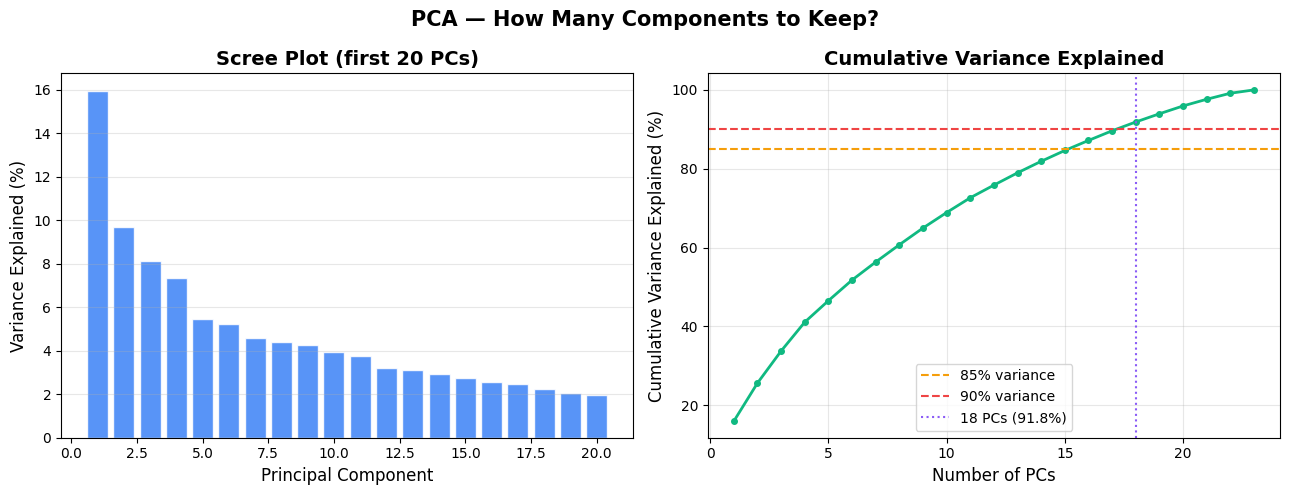

In [ ]:
# PCA
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
            color="#3B82F6", alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Variance Explained (%)", fontsize=12)
axes[0].set_title("Scree Plot (first 20 PCs)", fontsize=14, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100,
             "o-", color="#10B981", linewidth=2, markersize=4)
axes[1].axhline(85, color="#F59E0B", linestyle="--", linewidth=1.5, label="85% variance")
axes[1].axhline(90, color="#EF4444", linestyle="--", linewidth=1.5, label="90% variance")
axes[1].axvline(N_COMPONENTS, color="#8B5CF6", linestyle=":", linewidth=1.5, label="18 PCs (91.8%)")
axes[1].set_xlabel("Number of PCs", fontsize=12)
axes[1].set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
axes[1].set_title("Cumulative Variance Explained", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle("PCA — How Many Components to Keep?", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_scree.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
for threshold in [0.80, 0.85, 0.90]:
    n = np.searchsorted(cum_var, threshold) + 1
    print(f"PCs needed for {threshold*100:.0f}% variance: {n}")

PCs needed for 80% variance: 14
PCs needed for 85% variance: 16
PCs needed for 90% variance: 18


In [ ]:
# dimension reduction
N_COMPONENTS = 18

pca   = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features : {X_scaled.shape[1]}")
print(f"After PCA         : {X_pca.shape[1]} components")
print(f"Variance retained : {cum_var[N_COMPONENTS - 1]*100:.1f}%")

Original features : 23
After PCA         : 18 components
Variance retained : 91.9%


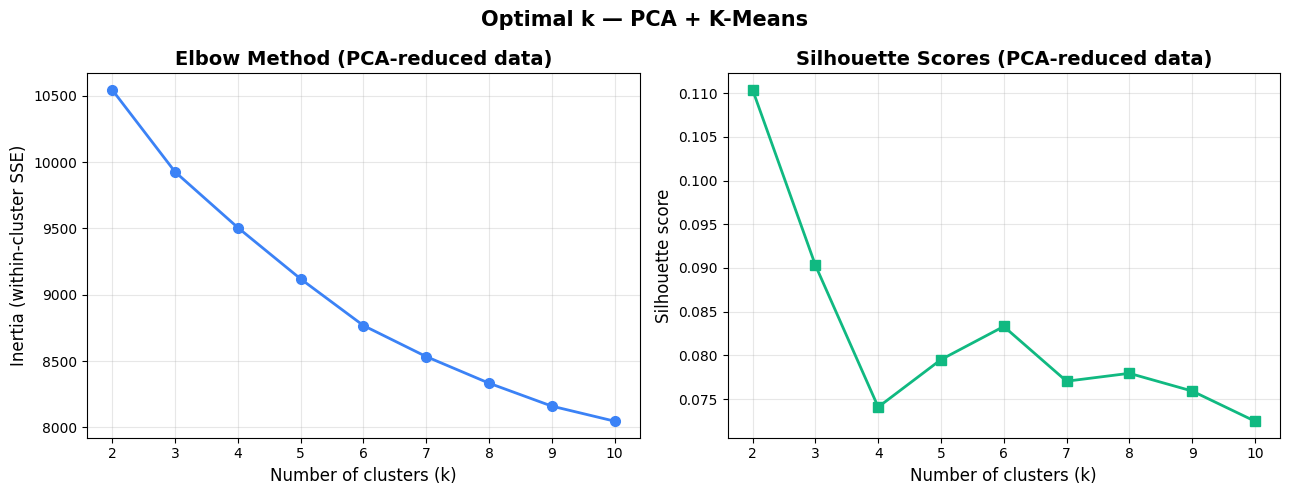


Silhouette scores (PCA-reduced):
  k=2: 0.1104
  k=3: 0.0903
  k=4: 0.0741
  k=5: 0.0795
  k=6: 0.0833
  k=7: 0.0770
  k=8: 0.0779
  k=9: 0.0759
  k=10: 0.0725


In [ ]:
# Elbow + Silhouette on PCA-reduced data
K_RANGE = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km       = KMeans(n_clusters=k, random_state=42, n_init=15, max_iter=500)
    labels_k = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#3B82F6", linewidth=2, markersize=7)
axes[0].set_xlabel("Number of clusters (k)", fontsize=12)
axes[0].set_ylabel("Inertia (within-cluster SSE)", fontsize=12)
axes[0].set_title("Elbow Method (PCA-reduced data)", fontsize=14, fontweight="bold")
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, "s-", color="#10B981", linewidth=2, markersize=7)
axes[1].set_xlabel("Number of clusters (k)", fontsize=12)
axes[1].set_ylabel("Silhouette score", fontsize=12)
axes[1].set_title("Silhouette Scores (PCA-reduced data)", fontsize=14, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.suptitle("Optimal k — PCA + K-Means", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_elbow_pca.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores (PCA-reduced):")
for k, s in zip(K_RANGE, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [ ]:
# Compare candidate k values
CANDIDATE_K = [2, 3, 5, 6]

for k in CANDIDATE_K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=30,
        max_iter=500
    )

    labels = km.fit_predict(X_pca)

    print("=" * 45)
    print(f"k = {k}")
    print(f"Silhouette = {silhouette_score(X_pca, labels):.4f}")
    print("Cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())
    print()

k = 2
Silhouette = 0.1104
Cluster sizes:
0    282
1    285
Name: count, dtype: int64

k = 3
Silhouette = 0.0903
Cluster sizes:
0    166
1    164
2    237
Name: count, dtype: int64

k = 5
Silhouette = 0.0795
Cluster sizes:
0     99
1    109
2    135
3    137
4     87
Name: count, dtype: int64

k = 6
Silhouette = 0.0832
Cluster sizes:
0     96
1    112
2     97
3    126
4     63
5     73
Name: count, dtype: int64



In [ ]:
# Compare interpretability of candidate k values
CANDIDATE_K = [2, 3, 5, 6]

for k in CANDIDATE_K:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=30,
        max_iter=500
    )

    labels = km.fit_predict(X_pca)

    # temporary dataframe
    temp = X.copy()
    temp["Cluster_temp"] = labels

    print("\n" + "=" * 80)
    print(f"K = {k}")
    print("=" * 80)

    for i in range(k):

        sub = temp[temp["Cluster_temp"] == i]

        # Top 5 genres by average listening frequency
        top5 = (
            sub[freq_num]
            .mean()
            .sort_values(ascending=False)
            .head(5)
        )

        top5_names = [
            c.replace("_enc", "")
             .replace("Frequency [", "")
             .replace("]", "")
            for c in top5.index
        ]

        print(f"\nCluster {i} (n={len(sub)})")
        print("Top genres:", ", ".join(top5_names))
        print(f"Hours/day: {sub['Hours per day'].mean():.2f}")
        print(f"BPM: {sub['BPM'].mean():.1f}")
        print(f"Explore: {sub['Exploratory_enc'].mean()*100:.0f}%")
        print(f"While working: {sub['While working_enc'].mean()*100:.0f}%")
        print(f"Instrumentalist: {sub['Instrumentalist_enc'].mean()*100:.0f}%")
        print(f"Composer: {sub['Composer_enc'].mean()*100:.0f}%")


K = 2

Cluster 0 (n=282)
Top genres: Pop, Hip hop, Rock, Rap, R&B
Hours/day: 3.64
BPM: 117.1
Explore: 87%
While working: 89%
Instrumentalist: 28%
Composer: 20%

Cluster 1 (n=285)
Top genres: Rock, Pop, Metal, Classical, Video game music
Hours/day: 2.71
BPM: 127.9
Explore: 59%
While working: 69%
Instrumentalist: 37%
Composer: 13%

K = 3

Cluster 0 (n=166)
Top genres: Rock, Pop, Hip hop, Lofi, Rap
Hours/day: 3.77
BPM: 115.4
Explore: 92%
While working: 95%
Instrumentalist: 50%
Composer: 33%

Cluster 1 (n=164)
Top genres: Pop, Hip hop, Rap, R&B, Rock
Hours/day: 3.27
BPM: 121.8
Explore: 73%
While working: 76%
Instrumentalist: 7%
Composer: 4%

Cluster 2 (n=237)
Top genres: Rock, Pop, Metal, Classical, Video game music
Hours/day: 2.68
BPM: 128.0
Explore: 59%
While working: 71%
Instrumentalist: 38%
Composer: 13%

K = 5

Cluster 0 (n=99)
Top genres: Rock, Pop, Hip hop, Rap, Classical
Hours/day: 1.53
BPM: 124.9
Explore: 61%
While working: 10%
Instrumentalist: 11%
Composer: 5%

Cluster 1 (n=109)

In [ ]:
# Fit final K-Means on PCA-reduced data

CHOSEN_K = 6

km_final = KMeans(
    n_clusters=CHOSEN_K,
    random_state=42,
    n_init=30,
    max_iter=500
)

cluster_labels = km_final.fit_predict(X_pca)

df_valid["Cluster"] = cluster_labels

print("\nCluster sizes:")
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)


Cluster sizes:
0     96
1    112
2     97
3    126
4     63
5     73
Name: count, dtype: int64


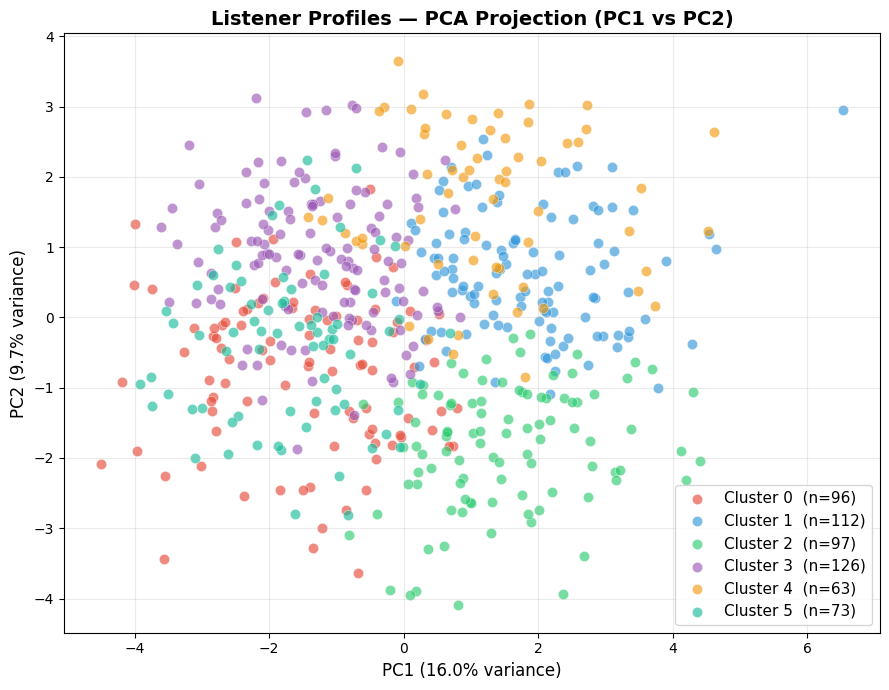

In [ ]:
#PCA 2-D projection (PC1 vs PC2)
PALETTE   = ["#E74C3C","#3498DB","#2ECC71","#9B59B6","#F39C12","#1ABC9C"]

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(CHOSEN_K):
    mask = cluster_labels == i
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=PALETTE[i], label=f"Cluster {i}  (n={mask.sum()})",
        alpha=0.65, s=55, edgecolors="white", linewidths=0.4
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("Listener Profiles — PCA Projection (PC1 vs PC2)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
frequency_vars = [c for c in df_valid.columns if c.startswith("Frequency [") and not c.endswith("_enc")]
freq_enc_cols  = [c + "_enc" for c in frequency_vars]
genre_labels   = [c.replace("Frequency [","").replace("]","") for c in frequency_vars]
binary_vars    = ["While working","Instrumentalist","Composer","Exploratory","Foreign languages"]
numeric_vars   = ["Age","Hours per day","BPM"]
MH_OUTCOMES    = ["Anxiety","Depression","Insomnia","OCD"]
EFFECT_ORDER   = ["Worsen","No effect","Improve"]
EFFECT_COLORS  = {"Worsen":"#E74C3C","No effect":"#95A5A6","Improve":"#27AE60"}

CLUSTER_NAMES = {
    0: "Low-Engagement Mixed Listeners",
    1: "Exploratory Mainstream Listeners",
    2: "Pop & Hip-Hop Listeners",
    3: "Rock & Metal Listeners",
    4: "Musician & Composer Listeners",
    5: "Classical & Instrumental Listeners"
}

LISTENER PROFILE ARCHETYPES
                                           n   Age Hrs/day  BPM Work% Explore% Instrument% Composer%                        Top genres Top fav genre
Cluster                                                                                                                                             
C0 — Low-Engagement Mixed Listeners       96  28.4     1.5  125   10%      53%         14%        6%                Rock, Pop, Hip hop          Rock
C1 — Exploratory Mainstream Listeners    112  24.6     3.7  119   96%      92%         26%        0%                Rock, Pop, Hip hop          Rock
C2 — Pop & Hip-Hop Listeners              97  21.1     3.6  116   88%      77%          8%        1%                 Pop, Hip hop, Rap           Pop
C3 — Rock & Metal Listeners              126  25.2     3.7  135   95%      76%         29%        9%                  Rock, Metal, Pop          Rock
C4 — Musician & Composer Listeners        63  24.7     3.9  113   97%      94%

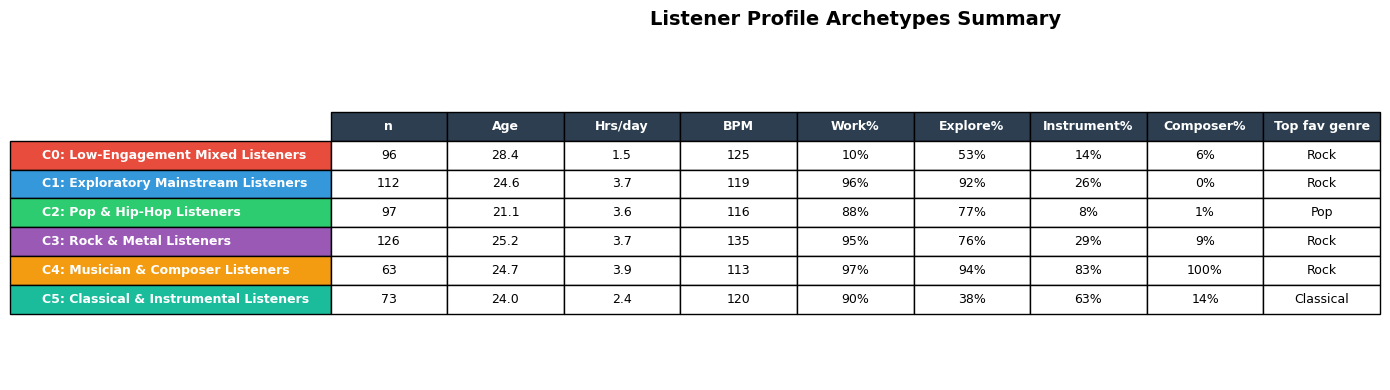

In [ ]:
# Listener Profile Archetypes
print("=" * 65)
print("LISTENER PROFILE ARCHETYPES")
print("=" * 65)

profile_rows = []

for i in range(CHOSEN_K):
    # X contains clustering features
    sub = X[cluster_labels == i]

    # df_valid contains original respondent information
    sub_df = df_valid[df_valid["Cluster"] == i]

    # Top 3 most frequently listened-to genres
    top3 = sub[freq_enc_cols].mean().sort_values(ascending=False).head(3)

    top3_names = [
        c.replace("_enc", "")
         .replace("Frequency [", "")
         .replace("]", "")
        for c in top3.index
    ]

    # Most common favorite genre
    fav_top = sub_df["Fav genre"].value_counts().index[0]

    profile_rows.append({
        "Cluster": f"C{i} — {CLUSTER_NAMES[i]}",
        "n": len(sub),

        # Age is NOT used in clustering;
        # only used here to describe the resulting clusters
        "Age": f"{sub_df['Age'].mean():.1f}",

        "Hrs/day": f"{sub['Hours per day'].mean():.1f}",
        "BPM": f"{sub['BPM'].mean():.0f}",
        "Work%": f"{sub['While working_enc'].mean()*100:.0f}%",
        "Explore%": f"{sub['Exploratory_enc'].mean()*100:.0f}%",
        "Instrument%": f"{sub['Instrumentalist_enc'].mean()*100:.0f}%",
        "Composer%": f"{sub['Composer_enc'].mean()*100:.0f}%",

        "Top genres": ", ".join(top3_names),
        "Top fav genre": fav_top,
    })


profile_df = pd.DataFrame(profile_rows).set_index("Cluster")

print(profile_df.to_string())


# ============================
# Visual profile table
# ============================

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

col_labels = [
    "n",
    "Age",
    "Hrs/day",
    "BPM",
    "Work%",
    "Explore%",
    "Instrument%",
    "Composer%",
    "Top fav genre"
]

table_data = profile_df[col_labels].values

row_labels = [
    f"C{i}: {CLUSTER_NAMES[i]}"
    for i in range(CHOSEN_K)
]

tbl = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# Colour row headers
for i in range(CHOSEN_K):
    tbl[(i + 1, -1)].set_facecolor(PALETTE[i])
    tbl[(i + 1, -1)].set_text_props(
        color="white",
        fontweight="bold"
    )

# Colour column headers
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor("#2C3E50")
    tbl[(0, j)].set_text_props(
        color="white",
        fontweight="bold"
    )

plt.title(
    "Listener Profile Archetypes Summary",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.savefig(
    "fig_profile_table.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

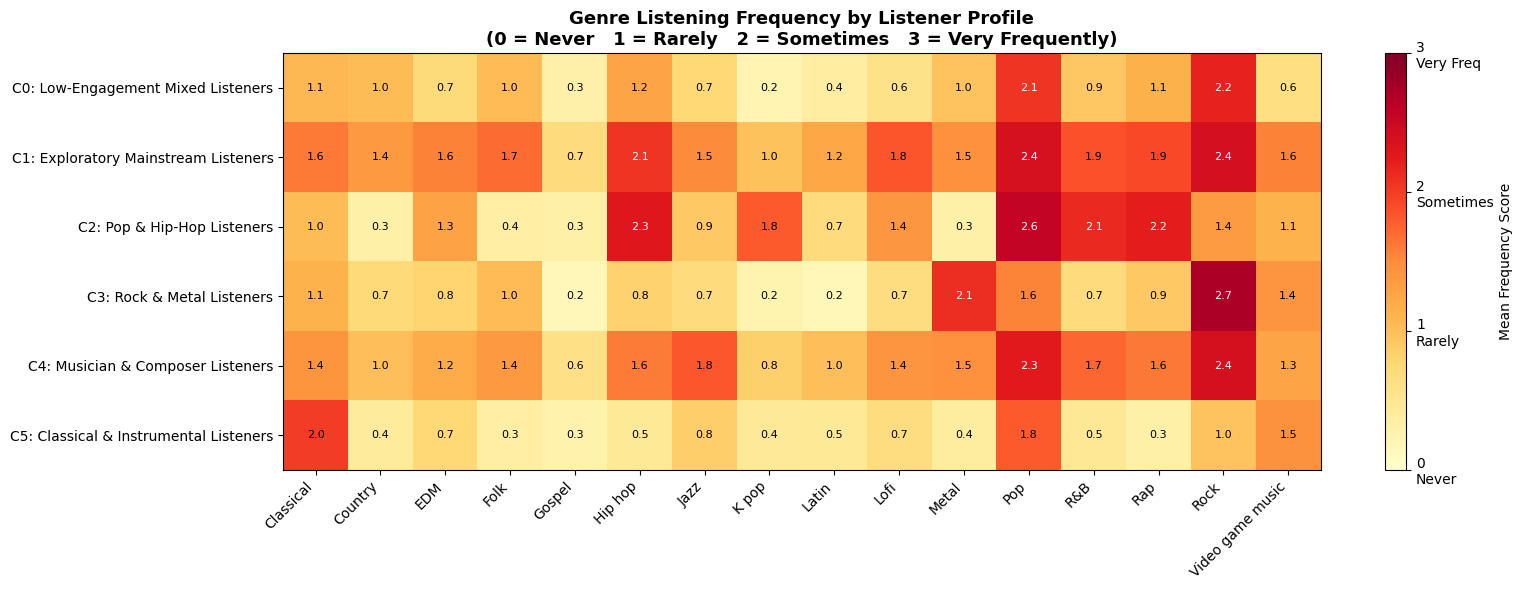

In [ ]:
# Genre Listening Heatmap
cluster_freq_means = np.array([
    X.loc[cluster_labels == i, freq_enc_cols].mean().values
    for i in range(CHOSEN_K)
])   # shape (K, 16)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(cluster_freq_means, aspect="auto", cmap="YlOrRd", vmin=0, vmax=3)

ax.set_xticks(range(len(genre_labels)))
ax.set_xticklabels(genre_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(CHOSEN_K))
ax.set_yticklabels(
    [f"C{i}: {CLUSTER_NAMES[i]}" for i in range(CHOSEN_K)],
    fontsize=10
)
ax.set_title(
    "Genre Listening Frequency by Listener Profile\n"
    "(0 = Never   1 = Rarely   2 = Sometimes   3 = Very Frequently)",
    fontsize=13, fontweight="bold"
)
cbar = plt.colorbar(im, ax=ax, label="Mean Frequency Score")
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(["0\nNever","1\nRarely","2\nSometimes","3\nVery Freq"])

# Annotate cells
for i in range(CHOSEN_K):
    for j in range(len(genre_labels)):
        v = cluster_freq_means[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                fontsize=8, color="white" if v > 2.0 else "black")

plt.tight_layout()
plt.savefig("fig_genre_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

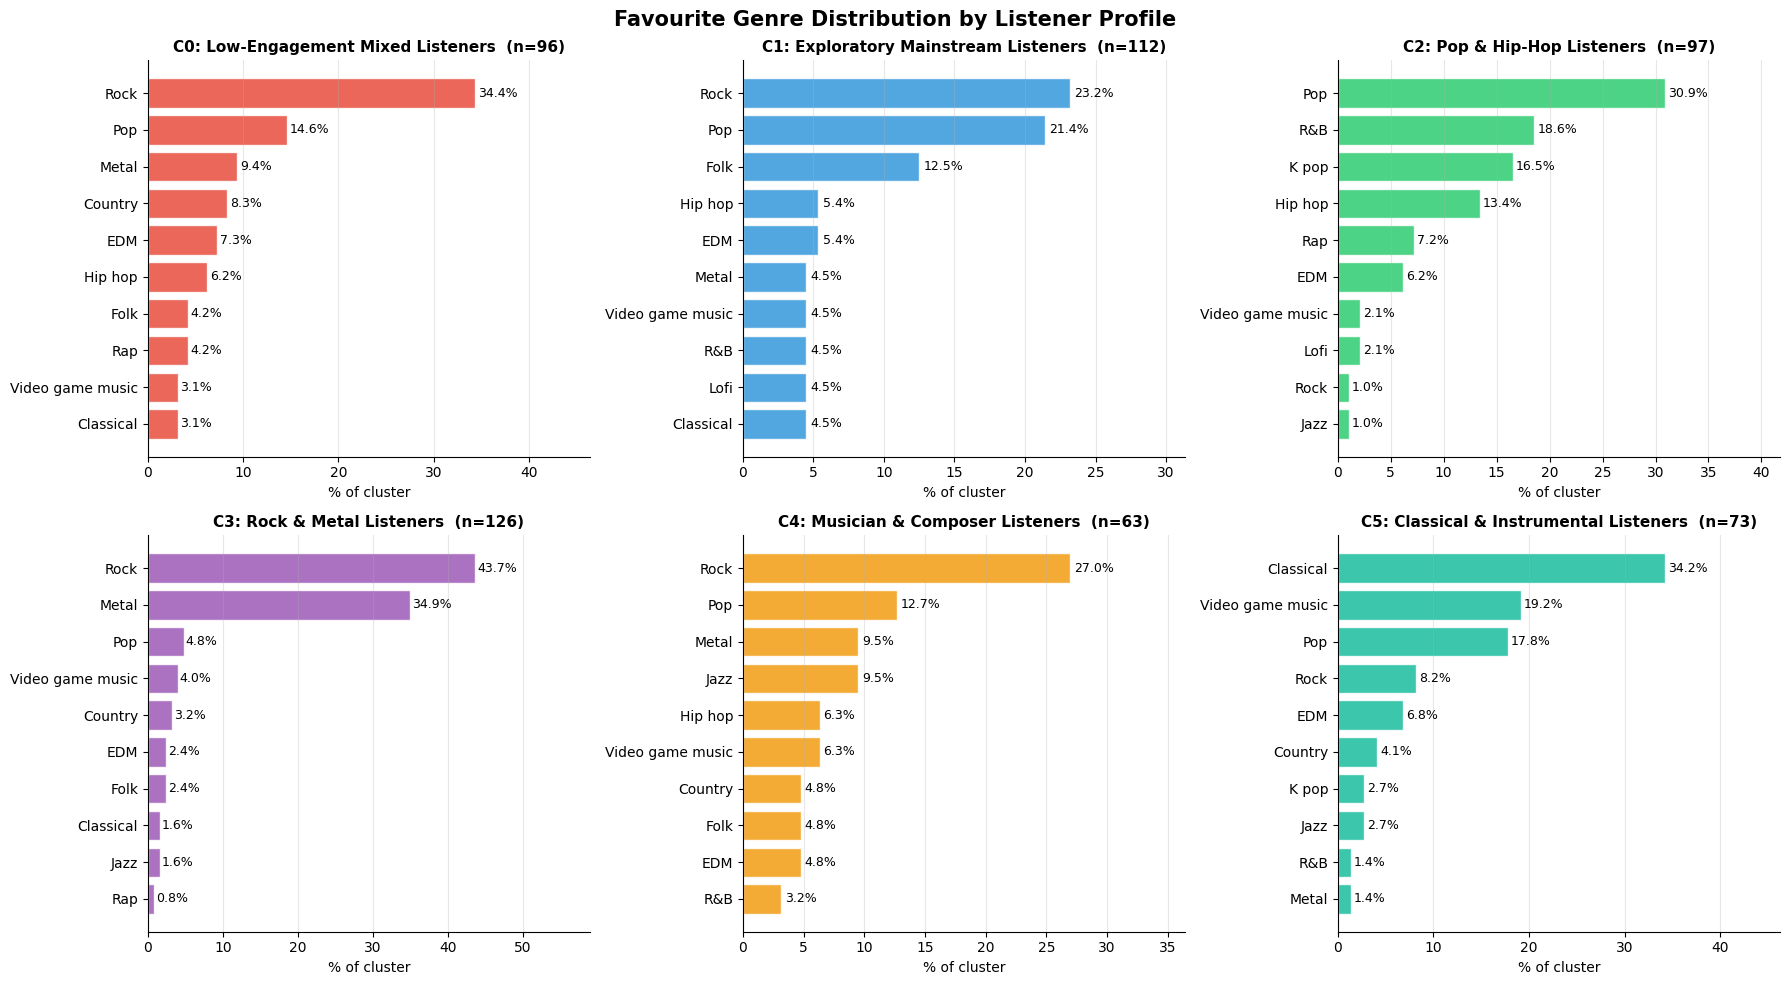

In [ ]:
# Favourite Genre Distribution per Profile
fav_counts = (df_valid.groupby(["Cluster","Fav genre"])
                       .size()
                       .reset_index(name="count"))
totals     = df_valid.groupby("Cluster").size().reset_index(name="total")
fav_pct    = fav_counts.merge(totals, on="Cluster")
fav_pct["pct"] = fav_pct["count"] / fav_pct["total"] * 100

ncols = 3
nrows = (CHOSEN_K + ncols - 1) // ncols # Dynamically calculate rows needed
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i in range(CHOSEN_K):
    ax   = axes[i]
    data = (fav_pct[fav_pct.Cluster == i]
            .sort_values("pct", ascending=True)
            .tail(10))
    bars = ax.barh(data["Fav genre"], data["pct"],
                   color=PALETTE[i], alpha=0.85, edgecolor="white")
    ax.set_title(f"C{i}: {CLUSTER_NAMES[i]}  (n={totals.loc[totals.Cluster==i,'total'].values[0]})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("% of cluster")
    ax.set_xlim(0, data["pct"].max() * 1.35)
    for bar, pct in zip(bars, data["pct"]):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

# Remove any unused subplots
for j in range(CHOSEN_K, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Favourite Genre Distribution by Listener Profile",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_fav_genre.png", dpi=150, bbox_inches="tight")
plt.show()

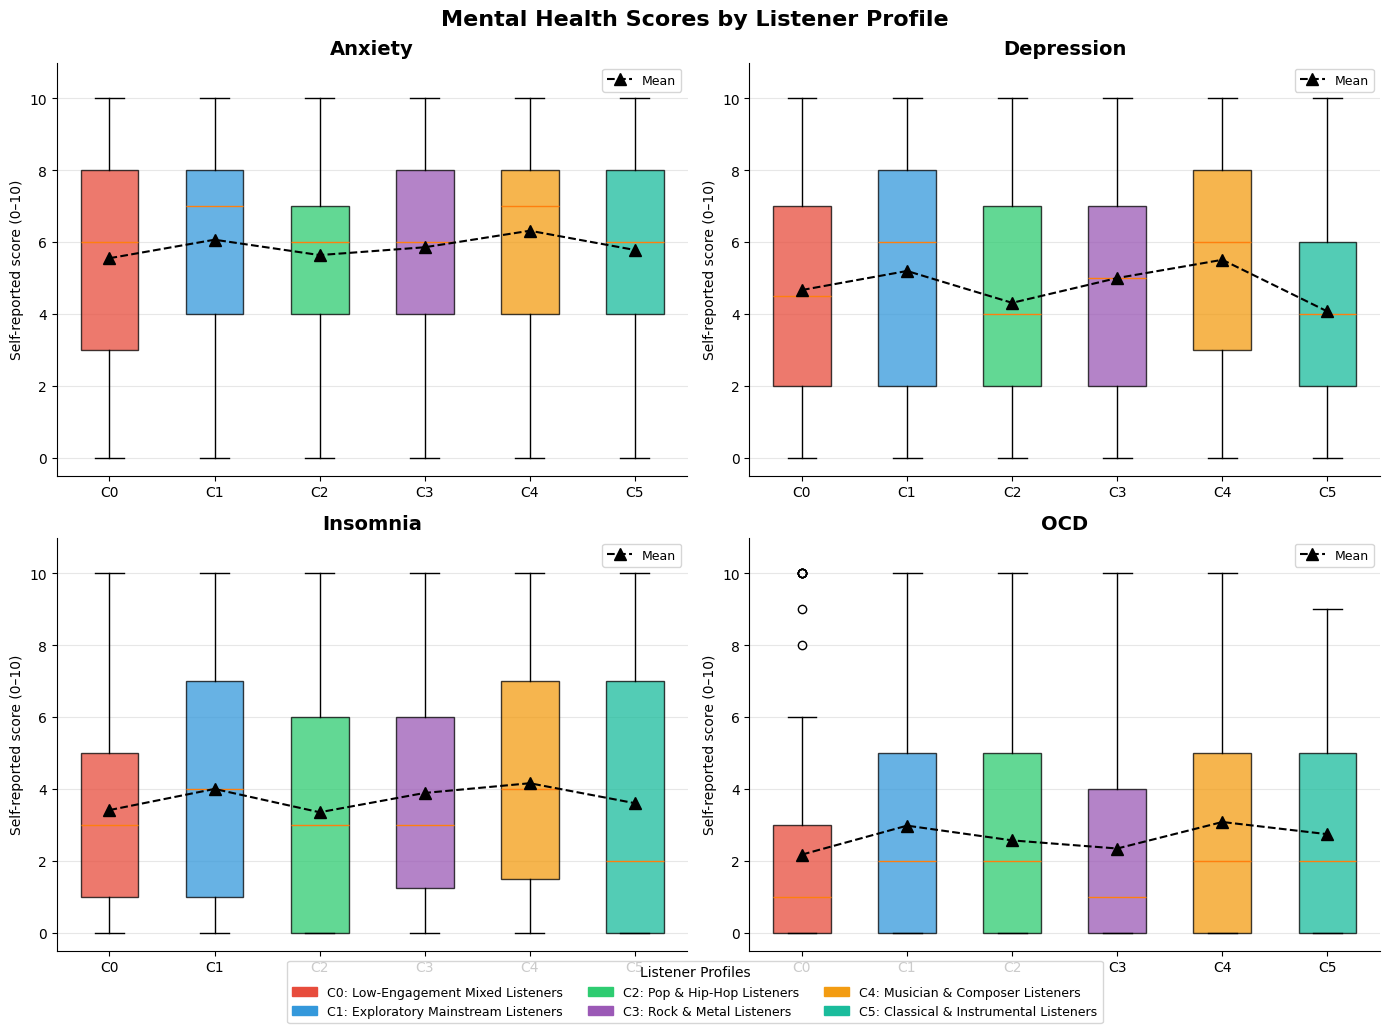

In [ ]:
# Mental Health Scores by Listener Profile  (box plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, outcome in zip(axes.flat, MH_OUTCOMES):
    groups = [df_valid[df_valid.Cluster == i][outcome].dropna().values
              for i in range(CHOSEN_K)]
    bp = ax.boxplot(groups, patch_artist=True, notch=False, widths=0.55)
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    means = [np.mean(g) for g in groups]
    ax.plot(range(1, CHOSEN_K + 1), means, "k^--", ms=8, zorder=5, label="Mean")
    ax.set_xticks(range(1, CHOSEN_K + 1))
    ax.set_xticklabels([f"C{i}" for i in range(CHOSEN_K)], fontsize=10)
    ax.set_title(outcome, fontsize=14, fontweight="bold")
    ax.set_ylabel("Self-reported score (0–10)")
    ax.set_ylim(-0.5, 11)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

# Legend for cluster colours
patches = [mpatches.Patch(color=PALETTE[i], label=f"C{i}: {CLUSTER_NAMES[i]}")
           for i in range(CHOSEN_K)]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.04),
           frameon=True, title="Listener Profiles")
plt.suptitle("Mental Health Scores by Listener Profile",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_mh_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

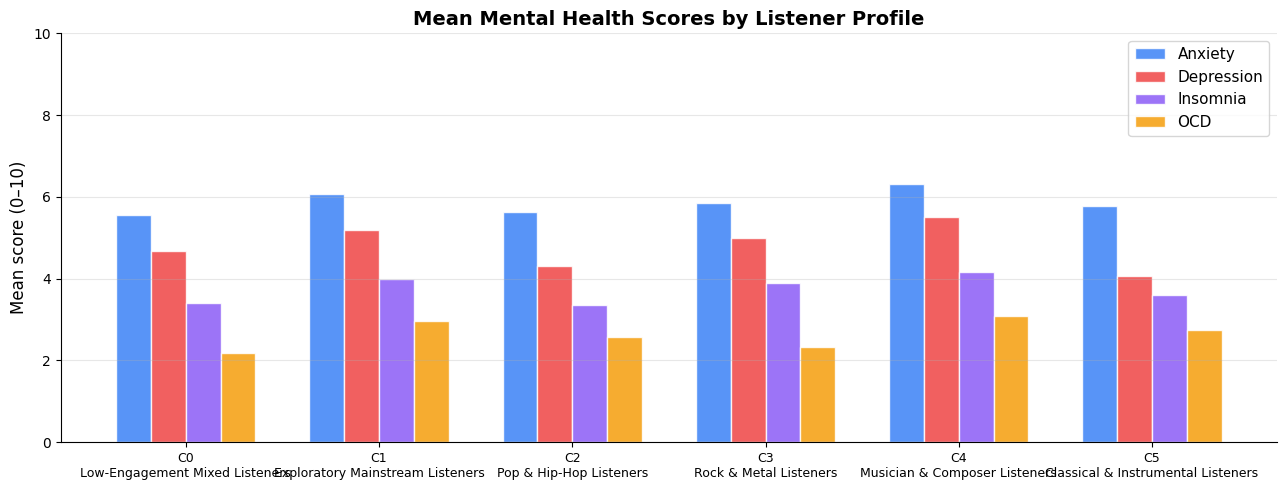

In [ ]:
# Mental Health Scores by Listener Profile  (mean bar chart)
mh_means = df_valid.groupby("Cluster")[MH_OUTCOMES].mean()

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(CHOSEN_K)
width = 0.18
colors_bar = ["#3B82F6","#EF4444","#8B5CF6","#F59E0B"]
for j, (outcome, col) in enumerate(zip(MH_OUTCOMES, colors_bar)):
    offset = (j - len(MH_OUTCOMES) / 2 + 0.5) * width
    ax.bar(x + offset, mh_means[outcome], width,
           label=outcome, color=col, alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"C{i}\n{CLUSTER_NAMES[i]}" for i in range(CHOSEN_K)],
                   fontsize=9)
ax.set_ylabel("Mean score (0–10)", fontsize=12)
ax.set_title("Mean Mental Health Scores by Listener Profile",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_mh_means_bar.png", dpi=150, bbox_inches="tight")
plt.show()

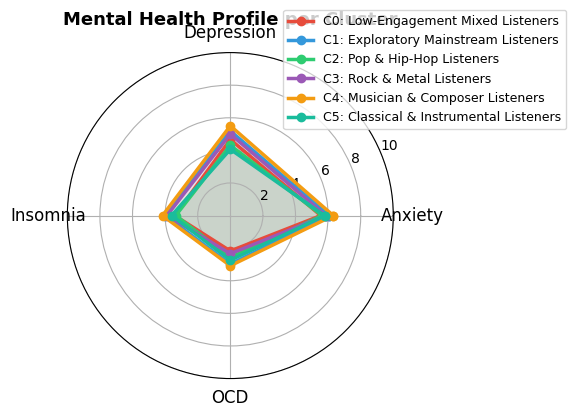

In [ ]:
# Mental Health Scores by Listener Profile  (radar chart)
angles = np.linspace(0, 2 * np.pi, len(MH_OUTCOMES), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i in range(CHOSEN_K):
    vals = mh_means.loc[i].tolist() + [mh_means.loc[i].tolist()[0]]
    ax.plot(angles, vals, "-o", color=PALETTE[i], linewidth=2.5,
            label=f"C{i}: {CLUSTER_NAMES[i]}", markersize=6)
    ax.fill(angles, vals, color=PALETTE[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(MH_OUTCOMES, fontsize=12)
ax.set_ylim(0, 10)
ax.set_title("Mental Health Profile per Cluster",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.55, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("fig_radar_mh.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#Statistical Tests
print("\n" + "=" * 65)
print("STATISTICAL TESTS — Mental Health × Cluster")
print("=" * 65)

n_pairs = CHOSEN_K * (CHOSEN_K - 1) // 2

print(f"\n[Kruskal-Wallis H-test]")
print(f"{'Outcome':<14}{'H-stat':>10}{'p-value':>12}{'Sig.':>8}")
print("-" * 46)
kw_results = {}
for outcome in MH_OUTCOMES:
    groups = [df_valid[df_valid.Cluster == i][outcome].dropna().values
              for i in range(CHOSEN_K)]
    H, p = kruskal(*groups)
    sig  = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    kw_results[outcome] = p
    print(f"{outcome:<14}{H:>10.3f}{p:>12.4f}{sig:>8}")

print(f"\n[One-way ANOVA — parametric, for reference]")
print(f"{'Outcome':<14}{'F-stat':>10}{'p-value':>12}{'Sig.':>8}")
print("-" * 46)
for outcome in MH_OUTCOMES:
    groups = [df_valid[df_valid.Cluster == i][outcome].dropna().values
              for i in range(CHOSEN_K)]
    F, p = stats.f_oneway(*groups)
    sig  = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    print(f"{outcome:<14}{F:>10.3f}{p:>12.4f}{sig:>8}")

print(f"\n[Pairwise Mann-Whitney U — post-hoc (Bonferroni-corrected, significant K-W only)]")
for outcome in MH_OUTCOMES:
    if kw_results[outcome] >= 0.05:
        print(f"\n  {outcome}: K-W not significant, skipping.")
        continue
    print(f"\n  {outcome}:")
    print(f"  {'Pair':<14}{'U-stat':>10}{'p (raw)':>12}{'p (Bonf)':>12}{'Sig.':>8}")
    print("  " + "-" * 58)
    for i, j in combinations(range(CHOSEN_K), 2):
        g1 = df_valid[df_valid.Cluster == i][outcome].dropna().values
        g2 = df_valid[df_valid.Cluster == j][outcome].dropna().values
        U, p_raw  = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        p_bonf    = min(p_raw * n_pairs, 1.0)
        sig = "***" if p_bonf<0.001 else "**" if p_bonf<0.01 else "*" if p_bonf<0.05 else "ns"
        print(f"  C{i} vs C{j}{'':>8}{U:>10.1f}{p_raw:>12.4f}{p_bonf:>12.4f}{sig:>8}")


STATISTICAL TESTS — Mental Health × Cluster

[Kruskal-Wallis H-test]
Outcome           H-stat     p-value    Sig.
----------------------------------------------
Anxiety            5.274      0.3834      ns
Depression        13.357      0.0202       *
Insomnia           5.578      0.3495      ns
OCD                8.885      0.1137      ns

[One-way ANOVA — parametric, for reference]
Outcome           F-stat     p-value    Sig.
----------------------------------------------
Anxiety            0.862      0.5065      ns
Depression         2.762      0.0178       *
Insomnia           1.014      0.4086      ns
OCD                1.452      0.2040      ns

[Pairwise Mann-Whitney U — post-hoc (Bonferroni-corrected, significant K-W only)]

  Anxiety: K-W not significant, skipping.

  Depression:
  Pair              U-stat     p (raw)    p (Bonf)    Sig.
  ----------------------------------------------------------
  C0 vs C1            4803.0      0.1837      1.0000      ns
  C0 vs C2         

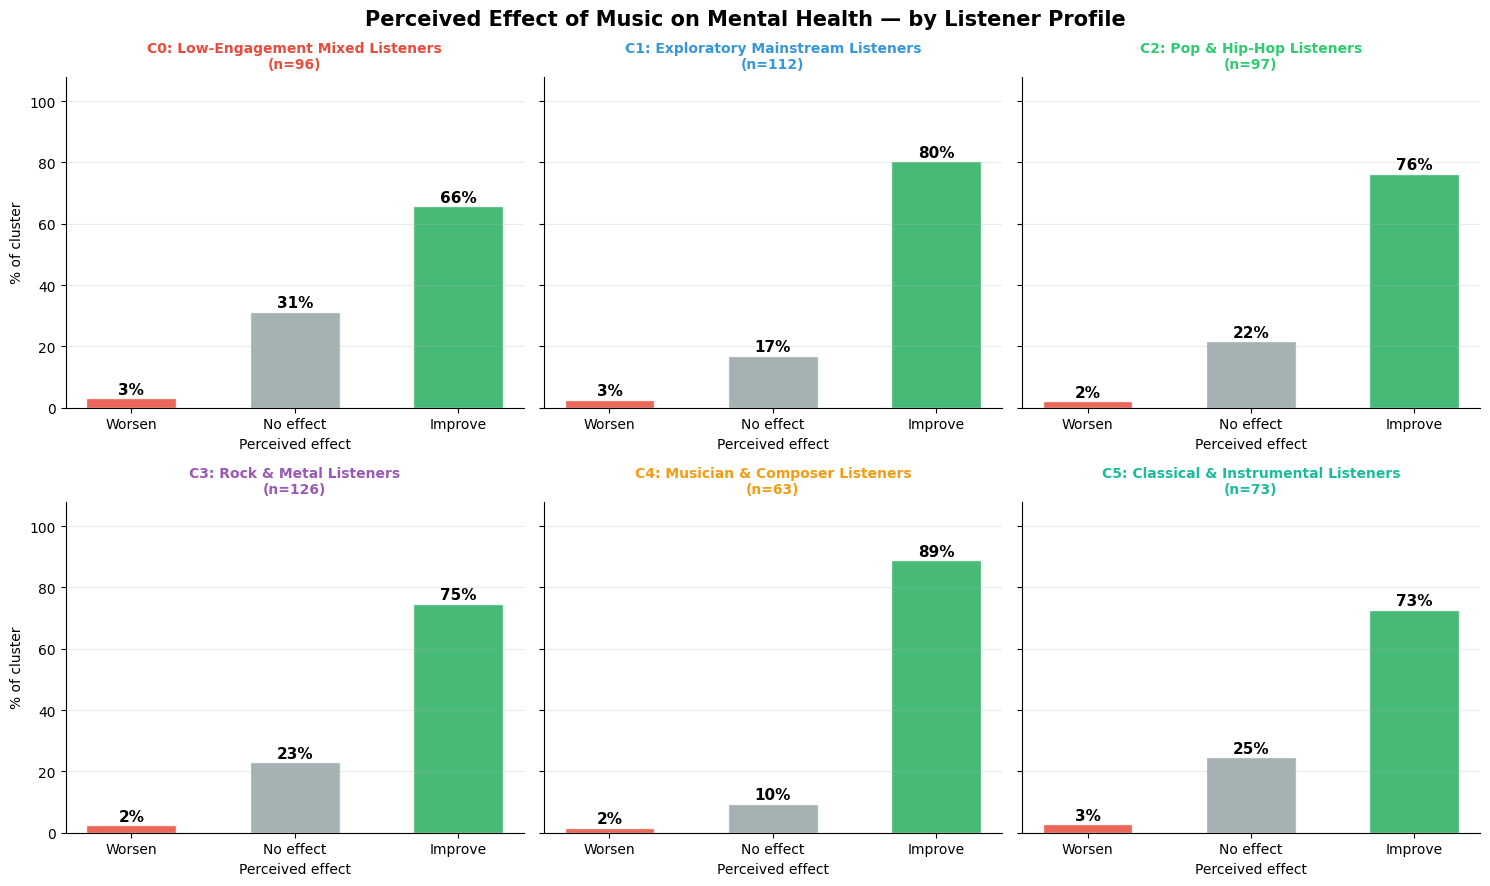

In [ ]:
# Perceived Effect of Music by Profile
eff_df  = df_valid.dropna(subset=["Music effects"]).copy()
eff_cnt = (eff_df.groupby(["Cluster","Music effects"])
                  .size()
                  .reset_index(name="n"))
eff_tot = eff_df.groupby("Cluster").size().reset_index(name="total")
eff_pct = eff_cnt.merge(eff_tot, on="Cluster")
eff_pct["pct"] = eff_pct["n"] / eff_pct["total"] * 100

# Dynamically calculate rows and columns for subplots
ncols = 3
nrows = (CHOSEN_K + ncols - 1) // ncols # Integer division for ceiling effect

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for i in range(CHOSEN_K):
    ax = axes[i]
    d  = (eff_pct[eff_pct.Cluster == i]
          .set_index("Music effects")
          .reindex(EFFECT_ORDER)
          .fillna(0)["pct"])
    colors = [EFFECT_COLORS[e] for e in EFFECT_ORDER]
    bars   = ax.bar(EFFECT_ORDER, d.values, color=colors,
                    alpha=0.85, edgecolor="white", width=0.55)
    for bar, v in zip(bars, d.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
    n_clust = eff_df[eff_df.Cluster == i].shape[0]
    ax.set_title(f"C{i}: {CLUSTER_NAMES[i]}\n(n={n_clust})",
                 fontsize=10, fontweight="bold", color=PALETTE[i])
    ax.set_ylim(0, 108)
    ax.set_xlabel("Perceived effect")
    if i % ncols == 0: # Adjusting for dynamic ncols
        ax.set_ylabel("% of cluster")
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

# Remove any unused subplots
for j in range(CHOSEN_K, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Perceived Effect of Music on Mental Health — by Listener Profile",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_music_effects.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Chi-square test
print("\n[Chi-square — Music effects × Cluster]")
ct = pd.crosstab(eff_df["Cluster"], eff_df["Music effects"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
sig = "***" if p_chi<0.001 else "**" if p_chi<0.01 else "*" if p_chi<0.05 else "ns"
print(f"  χ²({dof}) = {chi2:.3f},  p = {p_chi:.4f}  {sig}")
print("\nCrosstab (raw counts):")
print(ct.to_string())


[Chi-square — Music effects × Cluster]
  χ²(10) = 13.537,  p = 0.1952  ns

Crosstab (raw counts):
Music effects  Improve  No effect  Worsen
Cluster                                  
0                   63         30       3
1                   90         19       3
2                   74         21       2
3                   94         29       3
4                   56          6       1
5                   53         18       2
